In [1]:
import pandas as pd

In [31]:
data= pd.read_csv('/home/smjo/KG-gpt2/ver_7_factKG/Variation_results_test/gpt-4o-mini_maxiter_15/top_p_variation_num1.csv')
data

,top_p,mtr1,mtr2,mtr3
0,0.2,0.95,0.915789,0.831579
1,0.4,0.98,0.918367,0.836735
2,0.6,0.97,0.927835,0.855670
3,0.8,0.97,0.896907,0.793814
4,1.0,0.93,0.903226,0.806452


In [3]:
import matplotlib.pyplot as plt
import numpy as np

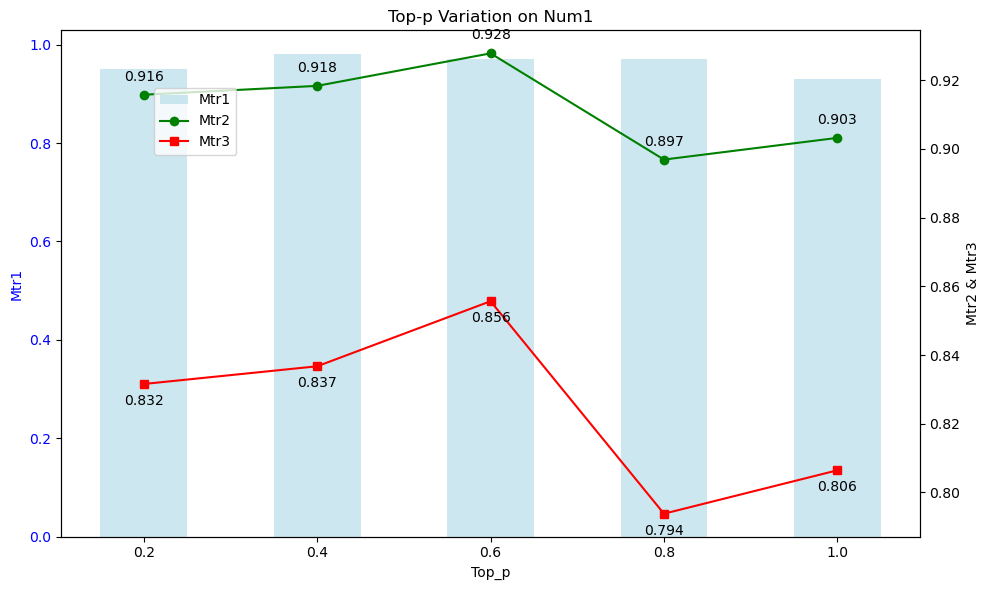

In [33]:
# Create DataFrame
df = pd.DataFrame(data)

# Plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot temperature as a bar plot
ax1.bar(df['top_p'], df['mtr1'], width=0.1, color='lightblue', alpha=0.6, label='Mtr1')
ax1.set_xlabel('Top_p')
ax1.set_ylabel('Mtr1', color='b')
ax1.tick_params(axis='y', labelcolor='blue')

# Create a second y-axis to plot mtr2 and mtr3
ax2 = ax1.twinx()

# Plot mtr2
ax2.plot(df['top_p'], df['mtr2'], color='g', marker='o', linestyle='-', label='Mtr2')
for i, txt in enumerate(df['mtr2']):
    ax2.annotate(f'{txt:.3f}', (df['top_p'][i], df['mtr2'][i]), textcoords="offset points", xytext=(0,10), ha='center')

# Plot mtr3
ax2.plot(df['top_p'], df['mtr3'], color='r', marker='s', linestyle='-', label='Mtr3')
for i, txt in enumerate(df['mtr3']):
    ax2.annotate(f'{txt:.3f}', (df['top_p'][i], df['mtr3'][i]), textcoords="offset points", xytext=(0,-15), ha='center')

ax2.set_ylabel('Mtr2 & Mtr3', color='k')
ax2.tick_params(axis='y', labelcolor='k')

# Add legend
fig.legend(loc='upper left', bbox_to_anchor=(0.1,0.9), bbox_transform=ax1.transAxes)

# Title
plt.title('Top-p Variation on Num1')

# Show the plot
plt.tight_layout()
plt.show()

In [ ]:
data= pd.read_csv('/home/smjo/KG-gpt2/ver_7_factKG/Variation_results_test/gpt-4o-mini_maxiter_15/top_p_variation_num1.csv')
data

In [8]:
data1= pd.read_csv('/home/smjo/KG-gpt2/ver_7_factKG/results_test/Iteration_limit_varation/only_result_multi_claim.csv')
data2 = pd.read_csv('/home/smjo/KG-gpt2/ver_7_factKG/results_test/Iteration_limit_varation/only_result_num1.csv')

In [11]:
multi_hop= pd.read_csv('/home/smjo/KG-gpt2/ver_7_factKG/results_test/Iteration_limit_varation/only_result_multi_hop.csv')

In [13]:
multi_hop

,iterlimit,mtr1,mtr2,mtr3
0,35,0.714286,1.000000,1.000000
1,32,0.714286,0.600000,0.200000
2,29,1.000000,0.714286,0.428571
3,26,0.428571,1.000000,1.000000
4,23,0.857143,1.000000,1.000000
5,20,0.571429,0.750000,0.500000
6,17,0.571429,1.000000,1.000000
7,14,0.714286,0.800000,0.600000
8,11,0.285714,0.500000,0.000000
9,8,0.285714,1.000000,1.000000


In [30]:
final_data = [['iterlimit',	'mtr1',	'mtr2',	'mtr3'],
              [32	,1.0,	0.600000,	0.200000],
              [29	,0.910000,	0.714286,	0.428571],
              [20	,0.771429,	0.750000,	0.500000],
              [17,	0.671429,	0.900000,	0.8700000],
              [14,	0.514286,	0.800000,	0.600000],
              
              [8,	0.285714,	1.000000,	1.000000],
              [7,	0.142857,	1.000000,	1.000000],
              [4,	0.000000,	0.000000,	0.000000]]

In [31]:
df = pd.DataFrame(final_data[1:],columns=final_data[0])
df

,iterlimit,mtr1,mtr2,mtr3
0,32,1.000000,0.600000,0.200000
1,29,0.910000,0.714286,0.428571
2,20,0.771429,0.750000,0.500000
3,17,0.671429,0.900000,0.870000
4,14,0.514286,0.800000,0.600000
5,8,0.285714,1.000000,1.000000
6,7,0.142857,1.000000,1.000000
7,4,0.000000,0.000000,0.000000


### 2 Agent F1 score 

In [9]:
import pandas as pd

# 1. 데이터 불러오기
def load_data(file_path):
    return pd.read_csv(file_path)

# 2. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(data):
    # 기권 샘플 제거
    total_samples = len(data)
    data = data[data["prediction"].str.lower() != "abstain"]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        prediction = row["prediction"].lower() == "true"
        ground_truth = row["gt_label"]

        # True Positives, False Positives, False Negatives
        tp = 1 if prediction and ground_truth else 0
        fp = 1 if prediction and not ground_truth else 0
        fn = 1 if not prediction and ground_truth else 0

        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if prediction == ground_truth:
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1, f1_scores

# Example usage
file_path = '/home/smjo/KG-gpt2/ver_7_factKG/results_test/gpt-4o-mini/15_only_result_multi_hop.csv'  # Replace with your CSV file path
data = load_data(file_path)
coverage, macro_f1, sample_wise_f1, hit_at_1, f1_scores = calculate_metrics(data)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


Coverage: 0.4300
Macro F1 Score: 0.8571
Sample-wise F1 Score: 0.4884
Hit@1: 0.8372


In [17]:
import pandas as pd

# 1. 데이터 불러오기
def load_data(file_path):
    return pd.read_csv(file_path)

# 2. Coverage, Macro F1, Sample-wise F1, Hit@1 계산 함수
def calculate_metrics(data):
    # 기권 샘플 제거
    total_samples = len(data)
    data = data[data["prediction"].str.lower() != "abstain"]
    non_abstain_samples = len(data)

    # Metrics 초기화
    total_tp = total_fp = total_fn = 0
    f1_scores = []
    hit_count = 0

    for _, row in data.iterrows():
        prediction = row["prediction"].lower() 
        ground_truth = row["gt_label"]
        print(prediction, ground_truth)

        # True Positives, False Positives, False Negatives
        if ground_truth==True and prediction=='true': tp =1
        else: tp=0
        
        if ground_truth==True and prediction=='false' : fn=1
        else: fn=0
        
        if ground_truth==False and prediction=='true' : fp=1
        else: fp=0


        total_tp += tp
        total_fp += fp
        total_fn += fn

        # Precision, Recall, F1 Score 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1 = (2 * precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        # Hit@1 계산
        if prediction == ground_truth:
            hit_count += 1

    # Coverage 계산
    coverage = non_abstain_samples / total_samples if total_samples > 0 else 0

    # Macro F1 계산
    macro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
    macro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
    macro_f1 = (2 * macro_precision * macro_recall) / (macro_precision + macro_recall) if (macro_precision + macro_recall) > 0 else 0

    # Sample-wise F1 계산
    sample_wise_f1 = sum(f1_scores) / len(f1_scores) if f1_scores else 0

    # Hit@1 계산
    hit_at_1 = hit_count / non_abstain_samples if non_abstain_samples > 0 else 0

    return coverage, macro_f1, sample_wise_f1, hit_at_1, f1_scores

# Example usage
file_path = '/home/smjo/KG-gpt2/ver_7_factKG/results_test/gpt-4o-mini/15_only_result_multi_hop.csv'  # Replace with your CSV file path
data = load_data(file_path)
coverage, macro_f1, sample_wise_f1, hit_at_1, f1_scores = calculate_metrics(data)
print(f"Coverage: {coverage:.4f}")
print(f"Macro F1 Score: {macro_f1:.4f}")
print(f"Sample-wise F1 Score: {sample_wise_f1:.4f}")
print(f"Hit@1: {hit_at_1:.4f}")


false False
true True
true True
true True
false False
true True
true True
true True
false True
false True
true True
true True
false False
false True
true True
false False
true True
false False
false True
true True
false False
false False
true True
false False
true True
true True
false False
false False
true True
true True
true True
true False
false False
false True
false False
true True
false True
true True
true True
false False
false False
true True
false False
Coverage: 0.4300
Macro F1 Score: 0.8571
Sample-wise F1 Score: 0.4884
Hit@1: 0.0000


In [13]:
len(f1_scores)

43